In [191]:
import xarray as xr
from geozarr_toolkit import validate_spatial, validate_proj, validate_attrs, validate_multiscales

In [192]:
zarr_url = 'http://127.0.0.1:8000/zarr/worldpop_population_yearly_sle'

In [193]:
dt = xr.open_datatree(zarr_url, engine="zarr")

In [194]:
for group in sorted(dt.groups):
    if dt[group].ds.data_vars:
        print(f"  {group}: {list(dt[group].ds.data_vars.keys())}")

  /0: ['pop_total']
  /1: ['pop_total']
  /2: ['pop_total']
  /3: ['pop_total']
  /4: ['pop_total']


In [195]:
zarr_metadata = dt.attrs
zarr_metadata

{'zarr_conventions': [{'uuid': '689b58e2-cf7b-45e0-9fff-9cfc0883d6b4',
   'schema_url': 'https://raw.githubusercontent.com/zarr-conventions/spatial/refs/tags/v1/schema.json',
   'spec_url': 'https://github.com/zarr-conventions/spatial/blob/v1/README.md',
   'name': 'spatial:',
   'description': 'Spatial coordinate information'},
  {'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f',
   'schema_url': 'https://raw.githubusercontent.com/zarr-experimental/geo-proj/refs/tags/v1/schema.json',
   'spec_url': 'https://github.com/zarr-experimental/geo-proj/blob/v1/README.md',
   'name': 'proj:',
   'description': 'Coordinate reference system information for geospatial data'},
  {'uuid': 'd35379db-88df-4056-af3a-620245f8e347',
   'schema_url': 'https://raw.githubusercontent.com/zarr-conventions/multiscales/refs/tags/v1/schema.json',
   'spec_url': 'https://github.com/zarr-conventions/multiscales/blob/v1/README.md',
   'name': 'multiscales',
   'description': 'Multiscale layout of zarr datasets'}],
 

In [196]:
validate_spatial(zarr_metadata)

(True, [])

In [197]:
validate_proj(zarr_metadata)

(True, [])

In [198]:
validate_multiscales(zarr_metadata)

(True, [])

In [199]:
# why empty respone?
validate_attrs(zarr_metadata)

{'spatial': [], 'proj': [], 'multiscales': [], 'zarr_conventions': []}

In [200]:
dt.groups

('/', '/0', '/1', '/2', '/3', '/4')

In [201]:
ds = dt['/0']
ds

<xarray.DataTree '0'>
Group: /0
    Dimensions:      (time: 16, y: 3695, x: 3635)
    Coordinates:
      * time         (time) datetime64[ns] 128B 2015-01-01 2016-01-01 ... 2030-01-01
      * y            (y) float64 30kB 10.0 9.999 9.998 9.997 ... 6.923 6.922 6.921
      * x            (x) float64 29kB -13.3 -13.3 -13.3 ... -10.27 -10.27 -10.27
        spatial_ref  int64 8B ...
    Data variables:
        pop_total    (time, y, x) float64 2GB ...
    Attributes:
        spatial:dimensions:      ['x', 'y']
        spatial:bbox:            [-13.300417333465003, 6.921250308314985, -10.272...
        spatial:transform_type:  affine
        spatial:shape:           [3635, 3695]
        spatial:registration:    pixel
        proj:code:               EPSG:4326
        zarr_conventions:        [{'uuid': '689b58e2-cf7b-45e0-9fff-9cfc0883d6b4'...

In [210]:
bo_ds = ds.sel(x=slice(-11.8, -11.66), y=slice(8.02, 7.88))
bo_ds

<xarray.DataTree '0'>
Group: /
    Dimensions:      (time: 16, y: 168, x: 168)
    Coordinates:
      * time         (time) datetime64[ns] 128B 2015-01-01 2016-01-01 ... 2030-01-01
      * y            (y) float64 1kB 8.02 8.019 8.018 8.017 ... 7.882 7.881 7.88
      * x            (x) float64 1kB -11.8 -11.8 -11.8 ... -11.66 -11.66 -11.66
        spatial_ref  int64 8B ...
    Data variables:
        pop_total    (time, y, x) float64 4MB ...
    Attributes:
        spatial:dimensions:      ['x', 'y']
        spatial:bbox:            [-13.300417333465003, 6.921250308314985, -10.272...
        spatial:transform_type:  affine
        spatial:shape:           [3635, 3695]
        spatial:registration:    pixel
        proj:code:               EPSG:4326
        zarr_conventions:        [{'uuid': '689b58e2-cf7b-45e0-9fff-9cfc0883d6b4'...

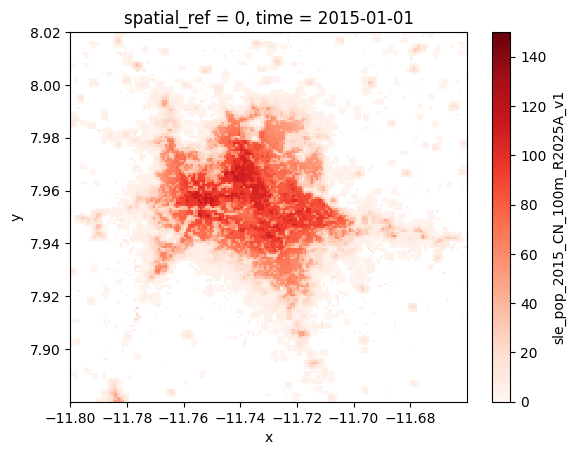

In [211]:
bo_ds.pop_total.sel(time="2015-01-01").plot(cmap='Reds', vmin=0, vmax=150)

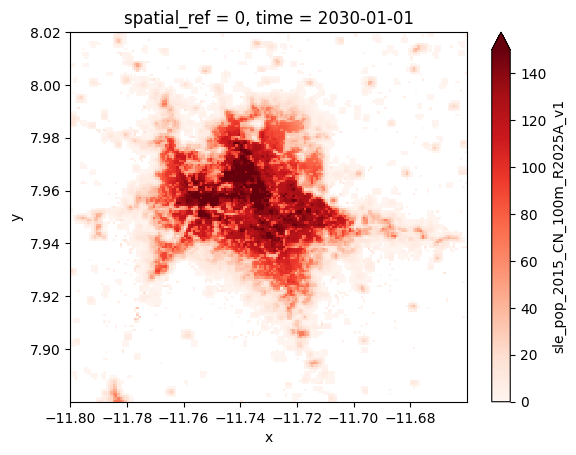

In [212]:
bo_ds.pop_total.sel(time="2030-01-01").plot(cmap='Reds', vmin=0, vmax=150)

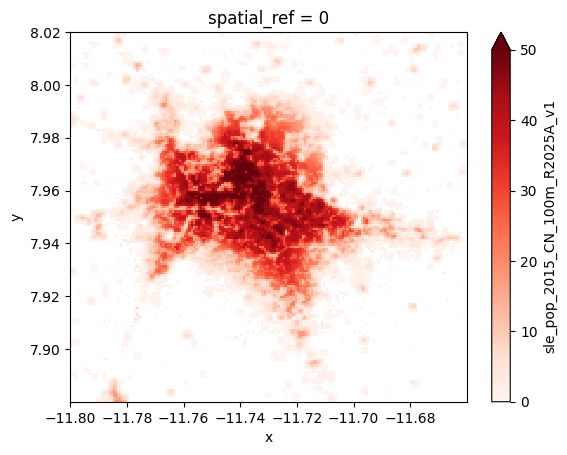

In [213]:
(bo_ds.pop_total.sel(time="2030-01-01") - bo_ds.pop_total.sel(time="2015-01-01")).plot(cmap='Reds', vmin=0, vmax=50)